Block 1: Tự động tìm file vừa thu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

In [ ]:
# 1. Đường dẫn đến kho dữ liệu thô
DATA_DIR = "../data/raw/"

# 2. Tìm tất cả các file .csv trong thư mục
list_of_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

if not list_of_files:
    print("❌ Ối, không tìm thấy file CSV nào trong data/raw cả!")
else:
    # TỰ ĐỘNG LẤY FILE CÓ THỜI GIAN TẠO MỚI NHẤT
    latest_file = max(list_of_files, key=os.path.getctime)
    file_name = os.path.basename(latest_file)
    
    print(f"✅ Đang phân tích file mới nhất: {file_name}")
    
    # 3. Đọc dữ liệu
    df = pd.read_csv(latest_file)

Block 2: Nhìn tổng thể raw data vừa thu được

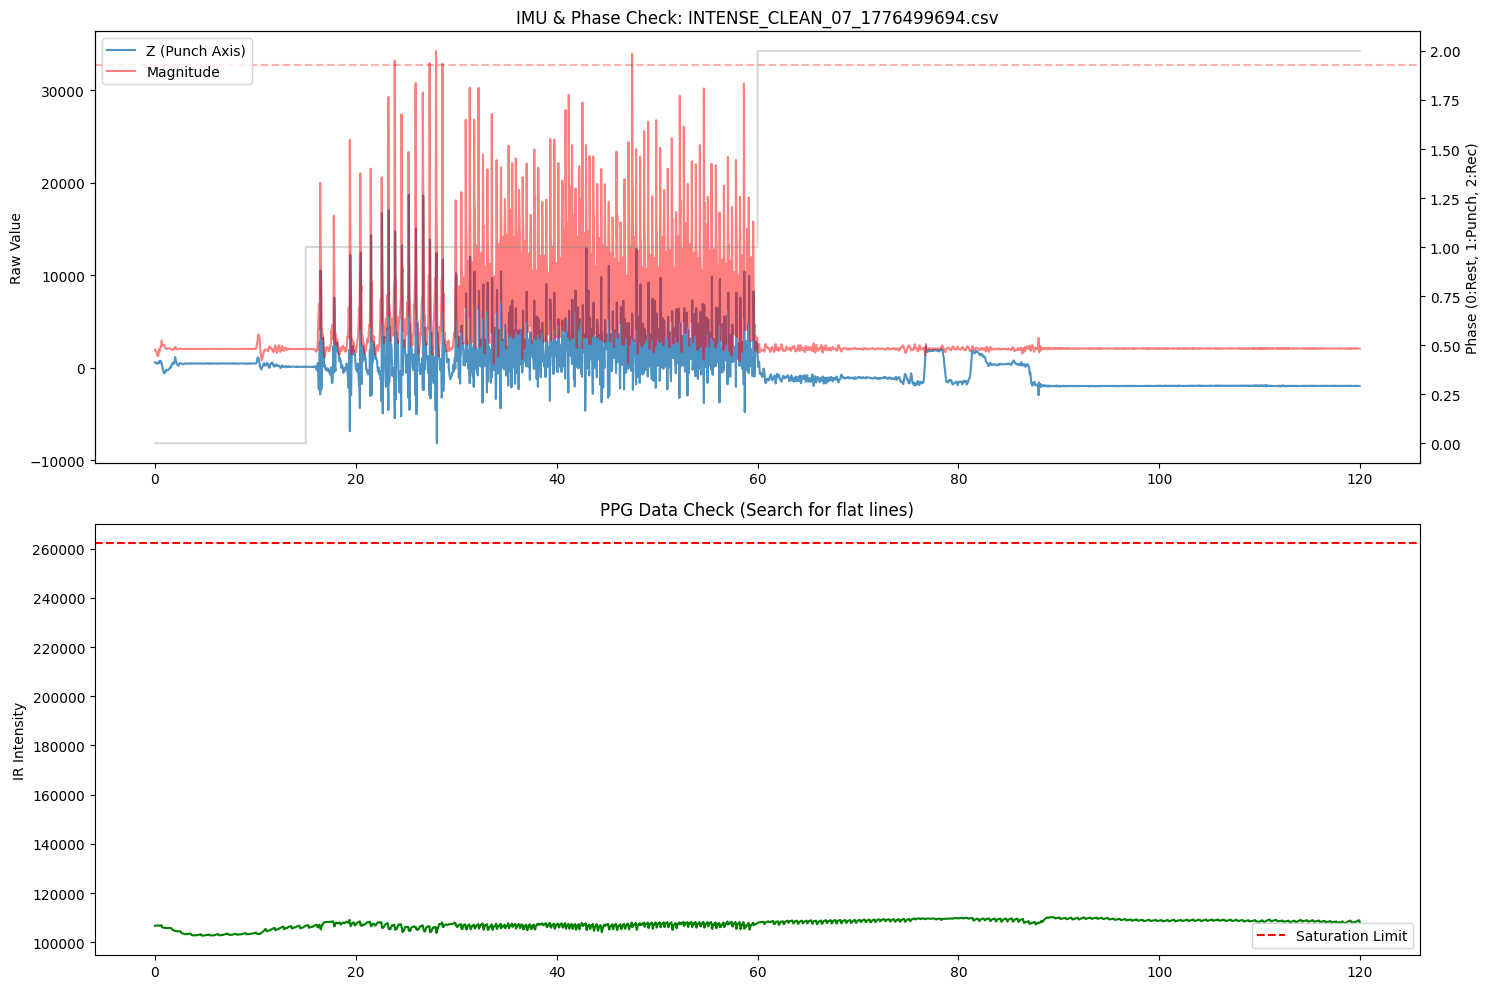

REPORT FOR INTENSE_CLEAN_07_1776499694.csv:
- Clipping (Force too strong): True
- Saturation (Light too bright): False


In [5]:
# Tính nhanh Acc_Mag để check
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# 1. Kiểm tra IMU & Phase
ax1.plot(df['Timestamp'], df['AccZ'], label='Z (Punch Axis)', alpha=0.8)
ax1.plot(df['Timestamp'], df['Acc_Mag'], label='Magnitude', color='red', alpha=0.5)
ax1.axhline(y=32767, color='red', linestyle='--', alpha=0.3) 
ax1.set_title(f"IMU & Phase Check: {os.path.basename(latest_file)}")
ax1.set_ylabel("Raw Value")
ax1.legend(loc='upper left')

# Vẽ Phase đè lên
ax1_twin = ax1.twinx()
ax1_twin.step(df['Timestamp'], df['Phase'], where='post', color='gray', alpha=0.3)
ax1_twin.set_ylabel("Phase (0:Rest, 1:Punch, 2:Rec)")

# 2. Kiểm tra PPG
ax2.plot(df['Timestamp'], df['Heart_IR'], color='green')
ax2.axhline(y=262143, color='red', linestyle='--', label='Saturation Limit')
ax2.set_title("PPG Data Check (Search for flat lines)")
ax2.set_ylabel("IR Intensity")
ax2.legend()

plt.tight_layout()
plt.show()

# REPORT
is_clipped = df['Acc_Mag'].max() >= 32760
is_saturated = df['Heart_IR'].max() >= 262140
print(f"REPORT FOR {os.path.basename(latest_file)}:")
print(f"- Clipping (Force too strong): {is_clipped}")
print(f"- Saturation (Light too bright): {is_saturated}")

Block 3: Check data từ IMU xem có bị clipping không

In [6]:
# Ngưỡng clipping của cảm biến 16-bit signed
CLIPPING_VAL_POS = 32767
CLIPPING_VAL_NEG = -32768

# Chọn trục muốn kiểm tra (ví dụ trục Z hướng đấm)
signal = df['AccZ']

# 1. Tìm các vị trí bị clipping
is_clipped = (signal == CLIPPING_VAL_POS) | (signal == CLIPPING_VAL_NEG)

# 2. Thuật toán tìm độ dài các chuỗi liên tiếp (Consecutive runs)
# Tạo một nhóm cho mỗi chuỗi liên tiếp
groups = (is_clipped != is_clipped.shift()).cumsum()
# Lọc ra chỉ những nhóm đang bị clipping và đếm số lượng phần tử
clipping_lengths = is_clipped[is_clipped].groupby(groups).size()

# 3. Kết quả
if clipping_lengths.empty:
    print("✅ Tuyệt vời: Không phát hiện clipping nào!")
else:
    max_run = clipping_lengths.max()
    total_clipped_samples = clipping_lengths.sum()
    
    print(f"⚠️ Cảnh báo: Phát hiện {len(clipping_lengths)} đoạn bị clipping.")
    print(f"Số mẫu bị xén liên tiếp dài nhất: {max_run} mẫu")
    print(f"Thời gian xén liên tiếp dài nhất: {max_run * 10} ms") # Vì fs = 100Hz
    print(f"Tổng số mẫu bị hỏng: {total_clipped_samples}")

✅ Tuyệt vời: Không phát hiện clipping nào!
